In [1]:
from sgt import SGT
import pandas as pd
import numpy as np
import pandarallel
import time
import matplotlib.pyplot as plt

In [2]:
SENTENCES_FPATH = './instruction_sentences.txt'

In [3]:
def export_fpath(fpath) -> pd.DataFrame:
    with open(fpath, 'r') as f:
        sentences = f.readlines()

    # Create a list with the split sentences
    sentences = [[idx, s.strip().split()] for idx, s in enumerate(sentences)]
    
    # Create a df with the split sentences and indexes
    df = pd.DataFrame(sentences, columns=['id', 'sequence'])

    return df

In [4]:
df = export_fpath(SENTENCES_FPATH)

In [5]:
df.head()

# sgt = SGT(kappa=1, 
#           flatten=True, 
#           lengthsensitive=False, 
#           mode='multiprocessing')
# sgt.fit_transform(df)

,id,sequence
0,0,"[GET-Window.execScript, GET-Window.google_tag_..."
1,1,"[GET-Window.latmconf, SET-Window.latmconf]"
2,2,"[GET-Window.document, GET-HTMLDocument.documen..."
3,3,"[GET-HTMLDocument.getElementById, GET-HTMLDocu..."
4,4,"[GET-Window.PAYPAL, GET-Window.navigator, GET-..."


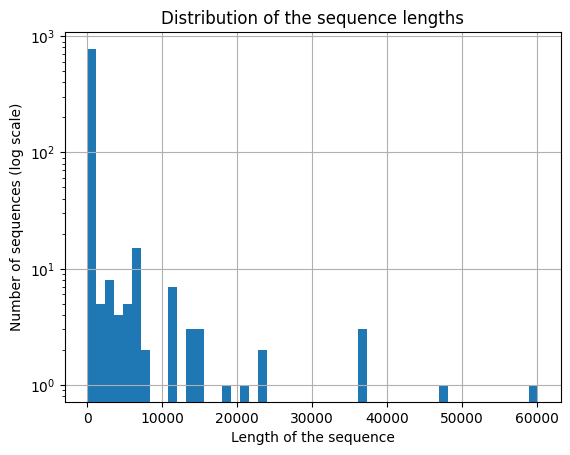

In [6]:
# Plot the distribution of the sequence lengths
df['sequence'].apply(len).hist(bins=50, log=True)
plt.title('Distribution of the sequence lengths')
plt.xlabel('Length of the sequence')
plt.ylabel('Number of sequences (log scale)')
plt.show()

In [7]:
# Plot the time taken to compute the SGT with different amounts of sequences
times = []
for n in range(5, 100, 10):
    print(f'Computing SGT with {n} sequences')
    start = time.time()
    sgt = SGT(kappa=1, 
          flatten=True, 
          lengthsensitive=False, 
          mode='default')
    sgt.fit_transform(df[:n])
    times.append(time.time() - start)

Computing SGT with 5 sequences
Computing SGT with 15 sequences
Computing SGT with 25 sequences
Computing SGT with 35 sequences
Computing SGT with 45 sequences
Computing SGT with 55 sequences
Computing SGT with 65 sequences
Computing SGT with 75 sequences
Computing SGT with 85 sequences
Computing SGT with 95 sequences


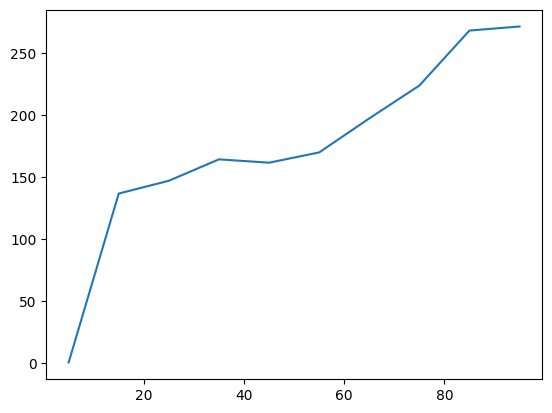

In [11]:
n = list(range(5, 100, 10))
plt.plot(n, times)